In [2]:
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy
from matplotlib.gridspec import GridSpec
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from connectivity.curves import CURVES


%load_ext autoreload
%autoreload 2
%aimport connectivity

base_path = "D:/data_paper"
patient_id = "EL027"
SOURCE = "output" # "publish_data/paper"
CLEAN_DATA_FILE = "out/clean_CR_IO/bad_responses_dict.json"
n_replications = 12
POWER_ANALYSIS_RESULT_FILE = f"../{SOURCE}/power_analysis/power_analysis_lf_merged.json" 
RESPONSES_FILE = f"../{SOURCE}/significant_responses/response_channels_lf.json" # "../publish_data/significant_responses/response_channels_lf.json"
CURVE_FITTING_FILE = f"../{SOURCE}/curve_fitting/curve_fitting_lf.json" # "../publish_data/significant_responses/response_channels_lf.json"
OUT_PATH = f"../{SOURCE}/power_analysis"
INTENSITIES_FILE = f"../{SOURCE}/CR_intensities.json"
SATURATED_THRESHOLD = 1.2

INCLUDE_REPLICATIONS_LIST_FULL = [12, 9, 6, 5, 4, 3, 2, 1]
INCLUDE_REPLICATIONS_LIST_REDUCED = [6, 5, 4, 3]
allowed_ids = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL013", "EL014", "EL015", "EL016"]

EXCLUDE_INTENSITIES_MATRICES_FULL = {
    17: [
        [],  # all intensities
        [12],
        [12, 14],
        [12, 14, 1],
        [12, 14, 1, 3],
        [12, 14, 1, 3, 5],
        [12, 14, 1, 3, 5, 7],
        [12, 14, 1, 3, 5, 7, 10],
        [12, 14, 1, 3, 5, 7, 10, 8],
        [12, 14, 1, 3, 5, 7, 10, 15],
        [12, 14, 1, 3, 5, 7, 10, 8, 15],
    ],
    18: [
        [],  # all intensities
        [2],
        [2, 13],
        [2, 13, 15],
        [2, 13, 15, 1],
        [2, 13, 15, 1, 4],
        [2, 13, 15, 1, 4, 6],
        [2, 13, 15, 1, 4, 6, 8],
        [2, 13, 15, 1, 4, 6, 8, 11],
        [2, 13, 15, 1, 4, 6, 8, 11, 9],
        [2, 13, 15, 1, 4, 6, 8, 11, 16],
        [2, 13, 15, 1, 4, 6, 8, 11, 9, 16],
    ],
    15: [
        [],  # all intensities
        [1],
        [1, 3],
        [1, 3, 5],
        [1, 3, 5, 7],
        [1, 3, 5, 7, 10],
        [1, 3, 5, 7, 10, 8],
        [1, 3, 5, 7, 10, 13],
        [1, 3, 5, 7, 10, 8, 13],
    ],
}
EXCLUDE_INTENSITIES_MATRICES_REDUCED =  {
    17: [
        [12, 14],
        [12, 14, 1, 3],
        [12, 14, 1, 3, 5, 7, 10],
        [12, 14, 1, 3, 5, 7, 10, 8, 15],
    ],
    18: [
        [2, 13, 15],
        [2, 13, 15, 1, 4],
        [2, 13, 15, 1, 4, 6, 8, 11],
        [2, 13, 15, 1, 4, 6, 8, 11, 9, 16],
    ],
    15: [[], [1, 3], [1, 3, 5, 7, 10], [1, 3, 5, 7, 10, 8, 13]],  # all intensities
}
EXCLUDE_INTENSITIES_MATRICES = {
    "complete": EXCLUDE_INTENSITIES_MATRICES_FULL,
    "zoom_full": EXCLUDE_INTENSITIES_MATRICES_FULL,
    "zoom_reduced": EXCLUDE_INTENSITIES_MATRICES_REDUCED,
}
INCLUDE_REPLICATIONS_LISTS = {
    "complete": INCLUDE_REPLICATIONS_LIST_FULL,
    "zoom_full": INCLUDE_REPLICATIONS_LIST_FULL,
    "zoom_reduced": INCLUDE_REPLICATIONS_LIST_REDUCED,
}

intensities = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0])
norm_intensities = intensities / np.max(intensities)

CURVE = CURVES["5P"]


EFFECT_SIZE = 0.1
USE_MIN_NORMALIZATION = True
MAX_ITERATIONS = 1000
EFFECT_SIZE_PRECISION = 0.001
N_REPLICATIONS_ORIGINAL = 12
N_SURROGATES = 500
SIGNIFICANCE_LEVEL = 0.05
R_SQUARED_THRESHOLD = 0.6
PARAM_NAMES = ["inflection_point", "upper_plateau"]# ["inflection_point"]#, "lower_plateau", "upper_plateau"]

N_FULL_INTENSITIES = 17
N_FULL_REPLICATIONS = 12

EXPERIMENTS = ["complete", "zoom_full", "zoom_reduced"]

SNR_COLUMN = "snr"
SATURATED_THRESHOLD = 1.2
DELTA_AUC_THRESHOLD = 0.05

In [3]:
from connectivity.load import parsed_list_to_numpy_array

with open(INTENSITIES_FILE, "r", encoding="utf-8") as filtered_df:
    intensities_lookup = json.load(filtered_df)

power_analysis_df = pd.read_json(POWER_ANALYSIS_RESULT_FILE, orient="records")
power_analysis_df = power_analysis_df[power_analysis_df["patient_id"].isin(allowed_ids)]
power_analysis_df["effect_size"] = power_analysis_df["effect_size"].round(3)
responses_df = pd.read_json(RESPONSES_FILE, orient="records")
responses_df = responses_df[responses_df["patient_id"].isin(allowed_ids)]

curve_fitting_df = pd.read_json(CURVE_FITTING_FILE, orient="records")
curve_fitting_df = curve_fitting_df[curve_fitting_df["patient_id"].isin(allowed_ids)]
curve_fitting_df["upper_plateau"] = curve_fitting_df["5P_params"].apply(lambda p: p[1] if p is not None else np.nan)
x_fit = np.linspace(0, 1, 1000)
def compute_exi_metrics(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return pd.Series({"exi": np.nan, "linear_exi": np.nan})
    
    y_fit = CURVES["5P"]["function"](x_fit, *p)
    exi = np.trapezoid(y_fit, x_fit)
    linear_exi = y_fit[0] + (y_fit[-1] - y_fit[0]) / 2
    return pd.Series({"exi": exi, "linear_exi": linear_exi})
curve_fitting_df[["exi", "linear_exi"]] = curve_fitting_df["5P_params"].apply(compute_exi_metrics)

responses_df = pd.merge(
    responses_df,
    curve_fitting_df,
    on=["patient_id", "stim_channel_name", "response_channel_name"],
    how="left"
)

print(len(power_analysis_df))
power_analysis_df = (
    power_analysis_df.groupby(["experiment", "param_name", "effect_size", "patient_id", "stim_channel_name", "response_channel_name"], as_index=False)
      .head(1)
)
print(len(power_analysis_df))
power_analysis_df = pd.merge(
    power_analysis_df,
    responses_df,
    on=["patient_id", "stim_channel_name", "response_channel_name"],
    how="right"
)
# remove low r squared
power_analysis_df = power_analysis_df[(power_analysis_df["5P_r_squared"] > R_SQUARED_THRESHOLD)]

40780
37563


In [4]:
exploded_rows = []

for experiment in EXPERIMENTS:
    print(f"Processing experiment: {experiment}")
    exclude_int_matrices = EXCLUDE_INTENSITIES_MATRICES[experiment]
    include_rep_list = INCLUDE_REPLICATIONS_LISTS[experiment]

    for param_name in PARAM_NAMES:
        if param_name == "upper_plateau" and experiment == "complete":
            continue
        rows_df = power_analysis_df[(power_analysis_df["experiment"] == experiment) & (power_analysis_df["param_name"] == param_name)]
        print(len(rows_df))
        # find effect sizes
        effect_sizes = rows_df["effect_size"].unique()
        for effect_size in effect_sizes:
            rows_df_effect = rows_df[rows_df["effect_size"] == effect_size]
            
            patient_ids =  rows_df_effect["patient_id"].unique()
            assert len(patient_ids) == len(allowed_ids), f"Not all patient ids present, {experiment}, {param_name}, {effect_size}"

            for pat_id in patient_ids:
                pat_df = rows_df_effect[rows_df_effect["patient_id"] == pat_id]
                intensities_patient = intensities_lookup[pat_id]
                assert len(pat_df) > 0, f"No data for patient {pat_id}, {experiment}, {param_name}, {effect_size}"
                
                raw_matrix = []
                raw_matrix_empirical = []
                for df_i, row_df in pat_df.iterrows():
                    surr_p_values = parsed_list_to_numpy_array(row_df["surr_p_values"])
                    surr_p_values_empirical = parsed_list_to_numpy_array(row_df["surr_p_values_empirical"])
                    
                    raw_matrix.append(surr_p_values)
                    raw_matrix_empirical.append(surr_p_values_empirical)

                raw_matrix = np.array(raw_matrix) # shape: (n_connection, n_int_red, n_rep_red)
                raw_matrix_empirical = np.array(raw_matrix_empirical)
                nan_mask = np.isnan(raw_matrix)
                raw_matrix[nan_mask] = 1 # set NaN to False (or fallback) # if REDUCE_ALONG_ONE_DIM_ONLY == True: all in-between cells are NaN
                nan_mask_empirical = np.isnan(raw_matrix_empirical)
                raw_matrix_empirical[nan_mask_empirical] = 1 # if REDUCE_ALONG_ONE_DIM_ONLY == True: all in-between cells are NaN

                # FDR correction
                corrected_matrix = scipy.stats.false_discovery_control(raw_matrix, method="bh", axis=0)
                
                # non-vectorized check
                # corrected_matrix_slow = np.empty_like(raw_matrix)
                # for i in range(raw_matrix.shape[1]):
                #     for j in range(raw_matrix.shape[2]):
                #         pcell = raw_matrix[:, i, j]
                #         corrected_matrix_slow[:, i, j] =  scipy.stats.false_discovery_control(pcell, method="bh", axis=0)
                # print(np.allclose(corrected_matrix_slow, corrected_matrix))

                corrected_matrix_empirical = scipy.stats.false_discovery_control(raw_matrix_empirical, method="bh", axis=0)
                
                for row_i, (_, row_df) in enumerate(pat_df.iterrows()):
                    for i_int_red in range(raw_matrix.shape[1]):
                        for j_rep_red in range(raw_matrix.shape[2]):
                            i_int_red_corrected = i_int_red
                            if raw_matrix.shape[1] != len(EXCLUDE_INTENSITIES_MATRICES_FULL[18]):
                                i_int_red_corrected = i_int_red + len(EXCLUDE_INTENSITIES_MATRICES_FULL[18]) - len(exclude_int_matrices[len(intensities_patient) + 1])
                            if experiment == "zoom_reduced" or experiment == "zoom_full":
                                # REDUCE_ALONG_ONE_DIM_ONLY is True, so ignore cells where both reduced
                                if not (i_int_red == 0 or j_rep_red == 0):
                                    continue
                            n_intensities = len(intensities_patient) - len(exclude_int_matrices[len(intensities_patient) + 1][i_int_red])
                            exploded_rows.append({
                                "experiment": experiment,
                                "param_name": param_name,
                                "effect_size": effect_size,
                                "patient_id": pat_id,
                                "stim_channel_name": row_df["stim_channel_name"],
                                "response_channel_name": row_df["response_channel_name"],
                                "n_intensities": n_intensities,
                                "has_all_intensities": n_intensities == len(intensities_patient),
                                "n_int_reduction_index_full_18": i_int_red_corrected, # use with caution, corresponds to the index of EXCLUDE_INTENSITIES_MATRICES_FULL[18]
                                "n_replications": include_rep_list[j_rep_red],
                                "n_stim": n_intensities * include_rep_list[j_rep_red],
                                "n_rep_reduction_index": j_rep_red,
                                "surr_p_value": raw_matrix[row_i, i_int_red, j_rep_red],
                                "surr_p_value_empirical": raw_matrix_empirical[row_i, i_int_red, j_rep_red],
                                "surr_p_value_fdr_corrected": corrected_matrix[row_i, i_int_red, j_rep_red],
                                "surr_p_value_empirical_fdr_corrected": corrected_matrix_empirical[row_i, i_int_red, j_rep_red],
                                "was_nan": nan_mask[row_i, i_int_red, j_rep_red], # only on fitted
                                # more properties of the connection
                                "upper_plateau": row_df["upper_plateau"],
                                "linear_exi": row_df["linear_exi"], 
                                "exi": row_df["exi"],
                                "snr": row_df[SNR_COLUMN],
                            })


exploded_df = pd.DataFrame(exploded_rows)
exploded_df["success"] = exploded_df["surr_p_value"] < SIGNIFICANCE_LEVEL
exploded_df["success_empirical"] = exploded_df["surr_p_value_empirical"] < SIGNIFICANCE_LEVEL
exploded_df["success_fdr_corrected"] = exploded_df["surr_p_value_fdr_corrected"] < SIGNIFICANCE_LEVEL
exploded_df["success_empirical_fdr_corrected"] = exploded_df["surr_p_value_empirical_fdr_corrected"] < SIGNIFICANCE_LEVEL

print(exploded_df[exploded_df["experiment"] == "zoom_full"]["surr_p_value"].sum())


Processing experiment: complete
1833
Processing experiment: zoom_full
11048
10776
Processing experiment: zoom_reduced
11030
0
85596.51098105368


### Power analysis

Supralinear: n=14422
Linear: n=3530
Infralinear: n=2611


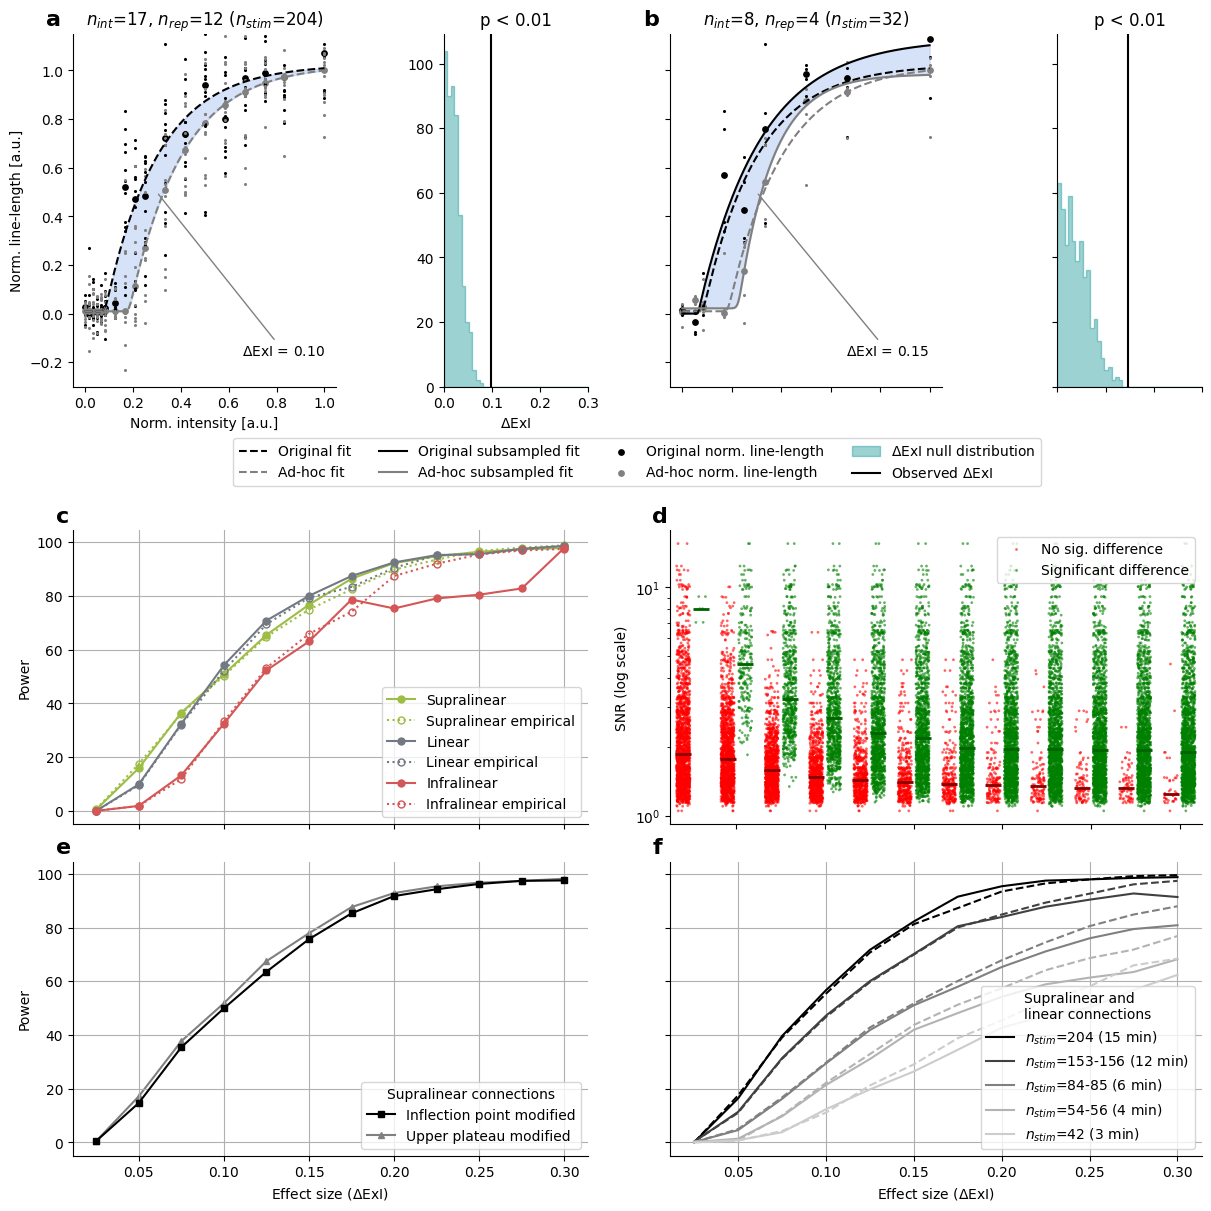

In [5]:
from connectivity.analyze import find_params_for_given_effect_size, fit_curve, normalize_ll_values, pick_random_replications, significant_exi_difference_testing
from matplotlib.lines import Line2D

from connectivity.load import parsed_list_to_numpy_array

def format_p(p):
    return "p < 0.01" if p < 0.01 else f"p = {p:.2f}"

np.random.seed(37)

# Exemplar connection
patient_id = "EL027"
stim_channel_name_pos = "A-L-3"
stim_channel_name_neg = "A-L-4"
stim_channel_name = stim_channel_name_pos + "-" + stim_channel_name_neg

response_channel_name_pos = "aH-L-3"
response_channel_name_neg = "aH-L-4"
response_channel_name = response_channel_name_pos + "-" + response_channel_name_neg

pat_row = responses_df[
    (responses_df["patient_id"] == patient_id)
    & (responses_df["stim_channel_name"] == stim_channel_name)
    & (responses_df["response_channel_name"] == response_channel_name)
].squeeze()

original_lls = parsed_list_to_numpy_array(
    pat_row["ll_values"]
)  # shape: (n_intensities, n_replications)
original_med_lls = np.nanmedian(original_lls, axis=1)
original_norm_med_lls = normalize_ll_values(
    original_med_lls, axis=0, use_min=USE_MIN_NORMALIZATION
)
shared_original_ll_max = np.nanpercentile(
    original_med_lls, 95, axis=0
)
shared_original_ll_min = np.nanmin(original_med_lls, axis=0)
original_norm_lls = normalize_ll_values(
    original_lls,
    max=shared_original_ll_max,
    min=shared_original_ll_min,
    use_min=USE_MIN_NORMALIZATION,
    axis=0,
)
x_fit = np.linspace(0, 1, 1000)
# get original ExI
try:
    original_params = fit_curve(
        curve_function=CURVE["function"],
        x=norm_intensities,
        y=original_norm_med_lls,
        initial_values=CURVE["initial_values"],
        bounds=CURVE["bounds"],
        max_iterations=MAX_ITERATIONS,
    )

    original_y_fit = CURVE["function"](x_fit, *original_params)
    original_y_pred = CURVE["function"](
        norm_intensities, *original_params
    )

    original_exi = np.trapezoid(original_y_fit, x_fit)
except RuntimeError as e:
    print(
        f"{patient_id}: {stim_channel_name}/{response_channel_name}: Optimization failed."
    )

if original_params[2] < 0.3:
    _target_exi = original_exi - EFFECT_SIZE
else:
    _target_exi = original_exi + EFFECT_SIZE

new_params = find_params_for_given_effect_size(
    curve=CURVE,
    orig_params=original_params,
    selected_param_index=2,
    target_exi=_target_exi,
    x=x_fit,
    precision=EFFECT_SIZE_PRECISION,
)
new_y_fit = CURVE["function"](x_fit, *new_params)
# generate new datapoints

original_y_pred = CURVE["function"](
    norm_intensities, *original_params
)
new_y_pred = CURVE["function"](norm_intensities, *new_params)
new_norm_lls = []
for i_int, _ in enumerate(norm_intensities):
    residuals = original_norm_lls[i_int] - original_y_pred[i_int]
    target_std = np.std(residuals)
    generated_lls = np.random.normal(
        loc=0,
        scale=1,
        size=N_REPLICATIONS_ORIGINAL,
    )
    b = target_std / np.std(generated_lls)
    # new_y_pred[i_int] == target median
    a = new_y_pred[i_int] - b * np.median(generated_lls)
    generated_lls = a + b * generated_lls

    new_norm_lls.append(generated_lls)
new_norm_lls = np.array(new_norm_lls)

norm_ll_values = pat_row["norm_med_lls"]

exclude_intensities_matrix = EXCLUDE_INTENSITIES_MATRICES_FULL.get(
    len(norm_intensities), None
)

def plot_cell(ax_l, ax_r, reduced_intensity, reduced_replication):
    # calculate surr
    int_reduced_intensities = np.delete(
        norm_intensities, exclude_intensities_matrix[reduced_intensity]
    )
    # ORIGINAL
    int_reduced_original_norm_lls = np.delete(
        original_norm_lls, exclude_intensities_matrix[reduced_intensity], axis=0
    )
    int_reduced_new_norm_lls = np.delete(
        new_norm_lls, exclude_intensities_matrix[reduced_intensity], axis=0
    )

    original_subset_lls = pick_random_replications(
        int_reduced_original_norm_lls,
        n_replications_to_select=INCLUDE_REPLICATIONS_LIST_FULL[reduced_replication],
    )
    original_subset_med_lls = np.nanmedian(
        original_subset_lls, axis=1
    )
    new_subset_lls = pick_random_replications(
        int_reduced_new_norm_lls,
        n_replications_to_select=INCLUDE_REPLICATIONS_LIST_FULL[reduced_replication],
    )
    new_subset_med_lls = np.nanmedian(new_subset_lls, axis=1)

    surr_p_value_empirical, surr_p_value = (
        significant_exi_difference_testing(
            norm_ll_values_1=original_subset_lls,
            norm_ll_values_2=new_subset_lls,
            n_surrogates=N_SURROGATES,
            intensities=int_reduced_intensities,
            curve=CURVE,
            ax=ax_r,
            parallelize=False,
        )
    )
    # FIT CURVES - note that we now fit the subset curve twice. This could be improved
    try:
        original_subset_params = fit_curve(
            curve_function=CURVE["function"],
            x=int_reduced_intensities,
            y=original_subset_med_lls,
            initial_values=CURVE["initial_values"],
            bounds=CURVE["bounds"],
            max_iterations=MAX_ITERATIONS,
        )
        original_subset_y_fit = CURVE["function"](
            x_fit, *original_subset_params
        )
        original_subset_exi = np.trapezoid(
            original_subset_y_fit, x_fit
        )
        original_subset_y_pred = CURVE["function"](
            int_reduced_intensities, *original_subset_params
        )
        new_subset_params = fit_curve(
            curve_function=CURVE["function"],
            x=int_reduced_intensities,
            y=new_subset_med_lls,
            initial_values=CURVE["initial_values"],
            bounds=CURVE["bounds"],
            max_iterations=MAX_ITERATIONS,
        )
        new_subset_y_fit = CURVE["function"](
            x_fit, *new_subset_params
        )
        new_subset_y_pred = CURVE["function"](
            int_reduced_intensities, *new_subset_params
        )
        new_subset_exi = np.trapezoid(new_subset_y_fit, x_fit)

        ax_l.plot(
            x_fit,
            original_y_fit,
            color="black",
            label="Original fit",
            linestyle="dashed",
        )
        ax_l.plot(
            x_fit,
            new_y_fit,
            color="gray",
            label="Ad-hoc fit",
            linestyle="dashed",
        )
        if reduced_replication != 0:
            ax_l.plot(
                x_fit,
                original_subset_y_fit,
                color="black",
                label="Original subsampled fit" if reduced_replication != 0 else "_nolegend_",
            )
            ax_l.plot(
                x_fit,
                new_subset_y_fit,
                color="gray",
                label="Ad-hoc subsampled fit" if reduced_replication != 0 else "_nolegend_",
            )
            ax_l.fill_between( x_fit, original_subset_y_fit, new_subset_y_fit, color="#aec6f1", alpha=0.5, zorder=0)
        else:
            ax_l.fill_between( x_fit, original_y_fit, new_y_fit, color="#aec6f1", alpha=0.5, zorder=0)
            
        
    except:
        pass
    ax_r.set_title(f"{format_p(surr_p_value)}")
    # left
    ax_l.scatter(
        int_reduced_intensities,
        original_subset_med_lls,
        color="black",
        label="Original norm. line-length",
        s=15
    )
    ax_l.scatter(
        int_reduced_intensities,
        new_subset_med_lls,
        color="gray",
        label="Ad-hoc norm. line-length",
        s=15
    )
    for src in original_subset_lls.T:
        ax_l.scatter(
            int_reduced_intensities,
            src,
            color="black",
            label="_nolegend_",
            s=1.5,
        )
    for src in new_subset_lls.T:
        ax_l.scatter(
            int_reduced_intensities,
            src,
            color="gray",
            label="_nolegend_",
            s=1.5,
        )
    n_int = len(int_reduced_intensities) -1
    n_rep = INCLUDE_REPLICATIONS_LIST_FULL[reduced_replication]
    ax_l.set_title(
        "$n_{int}$=" +  f"{n_int}, " + "$n_{rep}$=" + f"{n_rep} " + "($n_{stim}$=" + f"{n_int*n_rep})"
    )
    ax_l.spines["top"].set_visible(False)
    ax_l.spines["right"].set_visible(False)
    ax_r.spines["top"].set_visible(False)
    ax_r.spines["right"].set_visible(False)

    return np.abs(new_subset_exi - original_subset_exi)


def plot_power_curve_categories(df, ax, param_names, n_replications, n_intensities):
    plot_colors = [["#D45656", "#D49A9A"], ["#737983", "#ADB6C9"], ["#9DBD44", "#CBE08F"]]

    categories = [
        ("Supralinear",  lambda df: ((df["upper_plateau"] < SATURATED_THRESHOLD)), plot_colors[2]),
        ("Linear",       lambda df: ((df["upper_plateau"] >= SATURATED_THRESHOLD) & (np.abs(df["linear_exi"] - df["exi"]) <= DELTA_AUC_THRESHOLD)), plot_colors[1]),        
        ("Infralinear",  lambda df: ((df["upper_plateau"] >= SATURATED_THRESHOLD) & (df["linear_exi"] - df["exi"] >  DELTA_AUC_THRESHOLD)), plot_colors[0]),
    ]
    if n_intensities == "max":
        filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"].isin(param_names)) & (df["n_replications"] == n_replications) & (df["has_all_intensities"] == True)]
    else:
        filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"].isin(param_names)) & (df["n_replications"] == n_replications) & (df["n_intensities"] == n_intensities)]
    
    for category_name, category_filter, category_colors in categories:
        agg_category = (
            filtered_df[category_filter(filtered_df)]
            .groupby(["effect_size"])
            .agg(avg_success=("success", "mean"), avg_success_fdr_corrected=("success_fdr_corrected", "mean"), avg_success_empirical=("success_empirical", "mean"), avg_success_empirical_fdr_corrected=("success_empirical_fdr_corrected", "mean"), count=("success", "count"))
        ).reset_index()

        print(f"{category_name}: n={len(filtered_df[category_filter(filtered_df)])}")

        ax.plot(agg_category["effect_size"], agg_category["avg_success_fdr_corrected"] * 100, label=f"{category_name}", color=category_colors[0],  marker="o", markersize=5)
        ax.plot(agg_category["effect_size"], agg_category["avg_success_empirical_fdr_corrected"] * 100, label=f"{category_name} empirical", color=category_colors[0], linestyle="dotted",  marker="o", markersize=5, markerfacecolor="none")
    #ax.set_xlabel("Effect size ($\\Delta$ExI)")
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.grid(True)
    ax.set_ylabel("Power")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# code for strip plots
def plot_success_stripplots(df, ax, param_names, n_replications, n_intensities):
    if n_intensities == "max":
        filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"].isin(param_names)) & (df["n_replications"] == n_replications) & (df["has_all_intensities"] == True)]
    else:
        filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"].isin(param_names)) & (df["n_replications"] == n_replications) & (df["n_intensities"] == n_intensities)]
    
    plot_colors = df["success"].map({True: "green", False: "red"})

    sns.stripplot(
        data=filtered_df,
        x="effect_size",
        y=SNR_COLUMN,
        hue="success_fdr_corrected",
        palette={True: "green", False: "red"},
        dodge=True,  # separate success/fail within each effect size
        alpha=0.6,
        jitter=0.3,  # spread out points horizontally to avoid overlap
        size=2,
        ax=ax,
        legend=True,
        zorder=1,
    )
    sns.pointplot(
        data=filtered_df,
        x="effect_size",
        y=SNR_COLUMN,
        hue="success_fdr_corrected",
        estimator=np.median,
        dodge=0.4,
        markersize=12,
        markers="_",  # horizontal line marker
        linestyles="",  # no line connecting points
        palette={True: "darkgreen", False: "darkred"},
        ax=ax,
        errorbar=None,
        legend=False,
        zorder=10,
    )

    # make it rasterized
    for coll in ax.collections:
        coll.set_rasterized(True)

    tick_values = sorted(df["effect_size"].round(3).unique().tolist())
    ticks = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
    ax.set_xticks([tick_values.index(x) for x in ticks])
    ax.set_xticklabels([f"{x:g}" for x in ticks])
    #ax.set_xlabel("Effect size ($\\Delta$ExI)")
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), visible=False)
    handles, labels = ax.get_legend_handles_labels()

    labels_mapping = {"True": "Significant difference", "False": "No sig. difference"}
    labels = [labels_mapping[label] for label in labels]
    ax.legend(handles, labels, title="", loc="upper right")
    ax.set_ylabel("SNR (log scale)")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def get_datapoint_curve(df, param_names, n_datapoints_min, n_datapoints_max, col):
    filtered_df = df[
        (df["param_name"].isin(param_names))
        & (df["n_stim"] >= n_datapoints_min)
        & (df["n_stim"] <= n_datapoints_max)
    ]

    agg = (
        filtered_df.groupby("effect_size")[col].mean()
        .reset_index()
    )
    return agg["effect_size"].values, agg[col].values, len(filtered_df)

def plot_datapoints_power_curves(
    ax,
    df,
    param_names,
    plot_params,
    col_of_interest="success_fdr_corrected",
):
    df = df[df["experiment"].isin(["zoom_full", "zoom_reduced"])]
    colors = [str(g) for g in [0.0, 0.25, 0.5, 0.7, 0.8]] # 0 = black, 1 = white
    for i_line, plot_param in enumerate(plot_params):
        filtered_df = df[df["experiment"].isin(["zoom_full", "zoom_reduced"])]
        n_datapoints_min = plot_param["n_datapoints_min"]
        n_datapoints_max = plot_param["n_datapoints_max"]
        x, y, n_rows = get_datapoint_curve(
            filtered_df,
            param_names=param_names,
            n_datapoints_min=n_datapoints_min,
            n_datapoints_max=n_datapoints_max,
            col=col_of_interest
        )
        x_emp, y_emp, n_rows_emp = get_datapoint_curve(
            filtered_df,
            param_names=param_names,
            n_datapoints_min=n_datapoints_min,
            n_datapoints_max=n_datapoints_max,
            col="success_empirical_fdr_corrected"
        )
        ax.plot(
            x,
            y*100,
            label="$n_{stim}$" + (f"={n_datapoints_min}-{n_datapoints_max} ({n_datapoints_max * 4.5 / 60:.0f} min)" if n_datapoints_min != n_datapoints_max else f"={n_datapoints_min} ({n_datapoints_min * 4.5 / 60:.0f} min)"),
            color=colors[i_line],
            linestyle="solid",
        )
        ax.plot(
            x_emp,
            y_emp*100,
            #label="$n_{stim}$" + (f"={n_datapoints_min}-{n_datapoints_max} ({n_datapoints_max * 4.5 / 60:.0f} min)" if n_datapoints_min != n_datapoints_max else f"={n_datapoints_min} ({n_datapoints_min * 4.5 / 60:.0f} min)"),
            color=colors[i_line],
            linestyle="dashed",
        )
    ax.set_xlabel("Effect size ($\\Delta$ExI)")
    ax.grid(True)
    #ax.set_ylabel("Power")
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.legend(loc="lower right", title="Supralinear and \nlinear connections")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_param_comparison(ax, df, param_names, n_replications, n_intensities):
    markers = {
        "inflection_point": "s",
        "upper_plateau": "^",
    }
    zorders = {
        "inflection_point": 2,
        "upper_plateau": 1,
    }
    colors = {
        "inflection_point": "black",
        "upper_plateau": "gray",
    }
    friendly_param_names = {
        "inflection_point": "Inflection point modified",
        "upper_plateau": "Upper plateau modified",
    }    
    friendly_param_names_empirical = {
        "inflection_point": "Inflection point modified empirical",
        "upper_plateau": "Upper plateau modified empirical",
    }
    for param_name in param_names:
        if n_intensities == "max":
            filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"] == param_name) & (df["n_replications"] == n_replications) & (df["has_all_intensities"] == True)]
        else:
            filtered_df = df[(df["experiment"] == "zoom_full") & (df["param_name"] == param_name) & (df["n_replications"] == n_replications) & (df["n_intensities"] == n_intensities)]
        
        agg_param = (
            filtered_df
            .groupby(["effect_size"])
            .agg(avg_success=("success", "mean"), avg_success_fdr_corrected=("success_fdr_corrected", "mean"), avg_success_empirical=("success_empirical", "mean"), avg_success_empirical_fdr_corrected=("success_empirical_fdr_corrected", "mean"), count=("success", "count"))
        ).reset_index()


        ax.plot(agg_param["effect_size"], agg_param["avg_success_fdr_corrected"] * 100, label=f"{friendly_param_names[param_name]}", color=colors[param_name],  marker=markers[param_name], markersize=5, zorder=zorders[param_name])
        #ax.plot(agg_param["effect_size"], agg_param["avg_success_empirical_fdr_corrected"] * 100, label=f"{friendly_param_names_empirical[param_name]}", color=colors[param_name], linestyle="dotted", markersize=5, marker=markers[param_name], markerfacecolor="none", zorder=zorders[param_name])
        
    ax.set_xlabel("Effect size ($\\Delta$ExI)")
    ax.grid(True)
    ax.set_ylabel("Power")
    ax.legend(loc="lower right", title="Supralinear connections")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


centralized_legend_handles = []
centralized_legend_labels = []

fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs = GridSpec(
    4,
    6,
    figure=fig,
    width_ratios=[1, 1, 1.75, 1, 1, 1.75], height_ratios=[1.2, 0.2, 1, 1]
)

ax_al = fig.add_subplot(gs[0, 0:2])
ax_al.set_title("a", loc="left", fontsize=16, fontweight="bold", x=-0.1)
ax_ar = fig.add_subplot(gs[0, 2])
ax_ar.set_xlim([0, 0.3])
delta_exi = plot_cell(ax_l=ax_al, ax_r=ax_ar, reduced_intensity=0, reduced_replication=0)
ax_al.annotate(
    rf"$\Delta$ExI = {delta_exi:.2f}",
    xy=(0.3, 0.5),  # point to region
    xycoords="data",
    xytext=(0.8, 0.1),   # text outside
    textcoords="axes fraction",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=1
    )
)


ax_al.set_xlabel("Norm. intensity [a.u.]")
ax_al.set_ylabel("Norm. line-length [a.u.]")
ax_al.set_ylim([-0.3, 1.15])
ax_ar.set_xlabel("$\\Delta$ExI")

ax_bl = fig.add_subplot(gs[0, 3:5], sharey=ax_al)
ax_bl.set_title("b", loc="left", fontsize=16, fontweight="bold", x=-0.1)
ax_br = fig.add_subplot(gs[0, 5], sharey=ax_ar, sharex=ax_ar)
delta_exi = plot_cell(ax_l=ax_bl, ax_r=ax_br, reduced_intensity=10, reduced_replication=4)
ax_bl.annotate(
    rf"$\Delta$ExI = {delta_exi:.2f}",
    xy=(0.3, 0.5),  # point to region
    xycoords="data",
    xytext=(0.8, 0.1),   # text outside
    textcoords="axes fraction",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=1
    )
)
plt.setp(ax_bl.get_yticklabels(), visible=False)
plt.setp(ax_bl.get_xticklabels(), visible=False)
plt.setp(ax_br.get_yticklabels(), visible=False)
plt.setp(ax_br.get_xticklabels(), visible=False)

handles, labels = ax_bl.get_legend_handles_labels()
centralized_legend_handles.extend(handles)
centralized_legend_labels.extend(labels)
handles, labels = ax_br.get_legend_handles_labels()
centralized_legend_handles.extend(handles)
centralized_legend_labels.extend(labels)

# rename label 7
centralized_legend_labels[6] = "$\\Delta$ExI null distribution"
centralized_legend_labels[7] = "Observed $\\Delta$ExI"

ax_fig_placeholder = fig.add_subplot(gs[1, :])
ax_fig_placeholder.axis("off")
ax_fig_placeholder.legend(
    centralized_legend_handles,
    centralized_legend_labels,
    loc="center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.60),
)

ax_c = fig.add_subplot(gs[2, 0:3])
ax_c.set_title("c", loc="left", fontsize=16, fontweight="bold", x=-0.033)
plot_power_curve_categories(df=exploded_df, ax=ax_c, param_names=["upper_plateau", "inflection_point"], n_replications=N_FULL_REPLICATIONS, n_intensities="max")

ax_d = fig.add_subplot(gs[2, 3:])
ax_d.set_title("d", loc="left", fontsize=16, fontweight="bold", x=-0.033)
plot_success_stripplots(
    df=exploded_df,
    n_replications=N_FULL_REPLICATIONS,
    n_intensities="max",
    ax=ax_d,
    param_names=["upper_plateau", "inflection_point"],
)

ax_e = fig.add_subplot(gs[3, :3], sharex=ax_c, sharey=ax_c)
ax_e.set_title("e", loc="left", fontsize=16, fontweight="bold", x=-0.033)
plot_param_comparison(
    ax_e,
    df=exploded_df[exploded_df["upper_plateau"] < SATURATED_THRESHOLD],
    param_names=["inflection_point", "upper_plateau"],
    n_replications=N_FULL_REPLICATIONS,
    n_intensities="max"
)

ax_f = fig.add_subplot(gs[3, 3:], sharex=ax_c, sharey=ax_c)
ax_f.set_title("f", loc="left", fontsize=16, fontweight="bold", x=-0.033)
# ax_f.set_title("Supralinear and linear")

plot_params = [
    {
        "n_datapoints_min": 204,
        "n_datapoints_max": 204,
    },
    {
        "n_datapoints_min": 153,
        "n_datapoints_max": 156,
    },
    {
        "n_datapoints_min": 84,
        "n_datapoints_max": 85,
    },
    # {
    #     "n_datapoints_min": 70,
    #     "n_datapoints_max": 72,
    # },
    {
        "n_datapoints_min": 54,
        "n_datapoints_max": 56,
    },
    {
        "n_datapoints_min": 42,
        "n_datapoints_max": 42,
    },
]

plot_datapoints_power_curves(
    ax_f,
    df= exploded_df[((exploded_df["upper_plateau"] < SATURATED_THRESHOLD))
        | (
            (exploded_df["upper_plateau"] >= SATURATED_THRESHOLD)
            & (np.abs(exploded_df["linear_exi"] - exploded_df["exi"]) <= DELTA_AUC_THRESHOLD)
        )],
    param_names=["upper_plateau", "inflection_point"],
    plot_params=plot_params,
)


#plt.savefig("../output/figures/figure4.pdf", bbox_inches="tight", dpi=300)
plt.savefig("../output/figures/figure4.svg", bbox_inches="tight", dpi=300)
plt.show()

1.7314400947203993e-43
2.091665833078297e-35


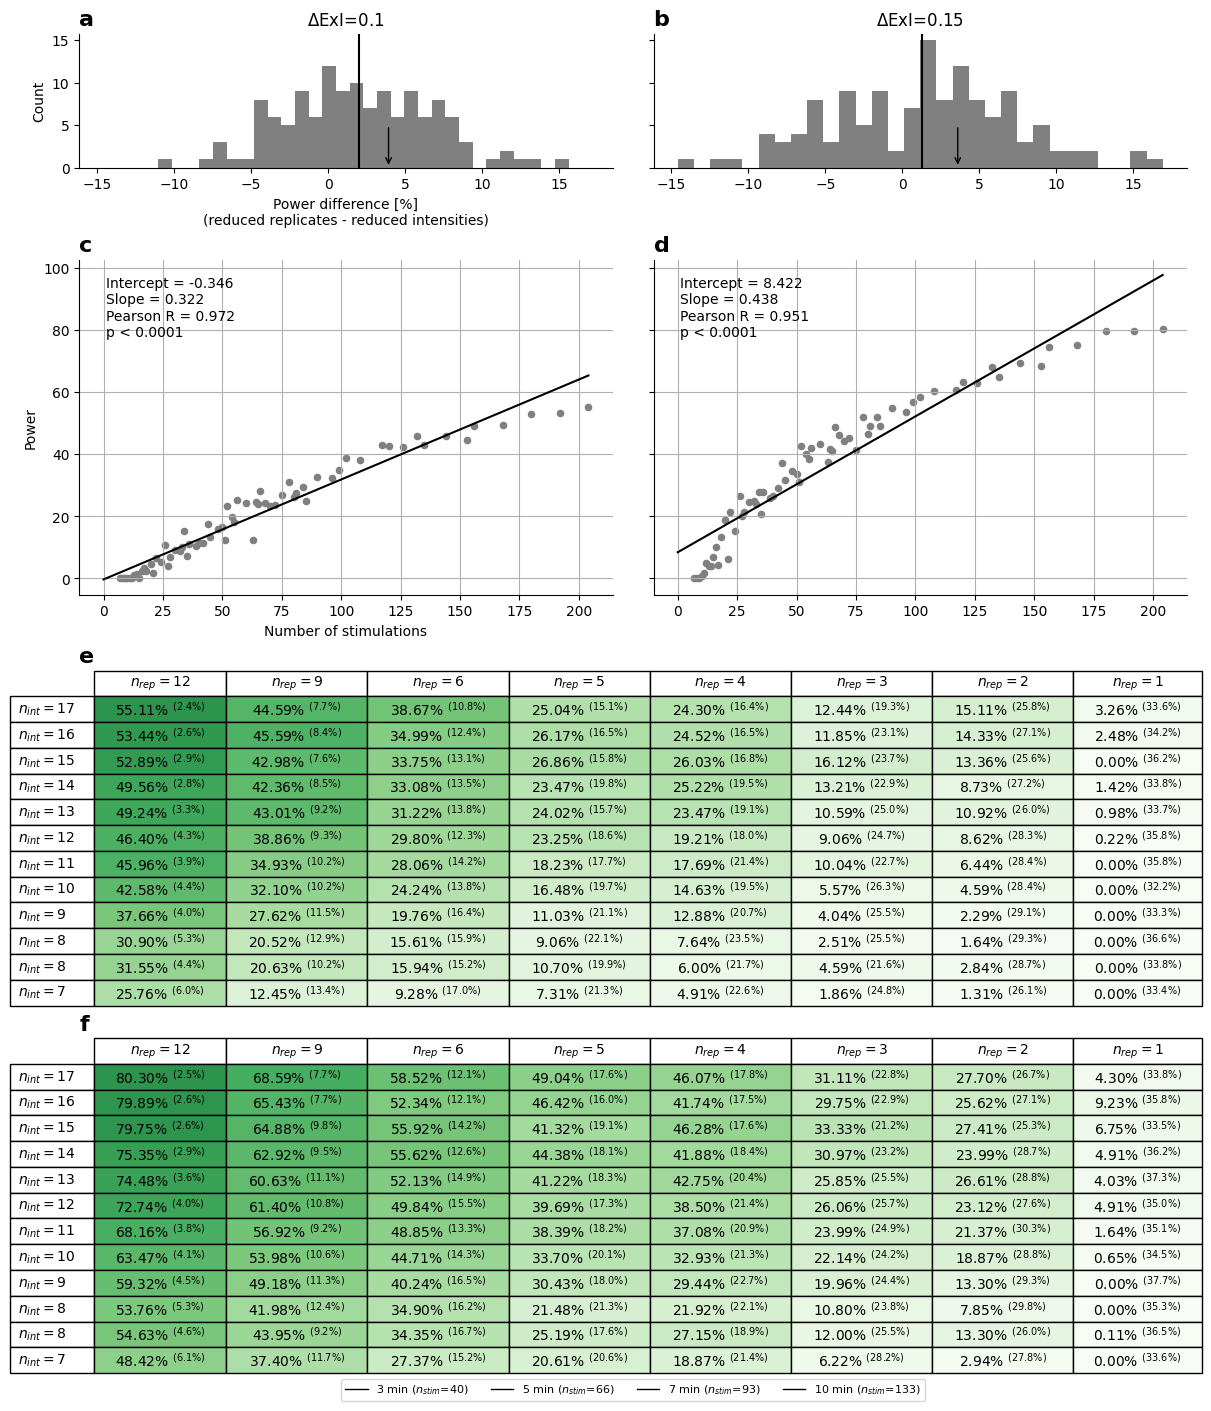

In [6]:
import itertools


def plot_diff(ax, param_name, effect_size, delta_datapoints, highlight_example=None):
    rows_df = exploded_df[(exploded_df["experiment"] == "complete") & (exploded_df["effect_size"] == effect_size) & (exploded_df["param_name"]== param_name)]

    power_matrix = []
    power_matrix_empirical = []
    for i_int_red, n_int_excluded in enumerate(EXCLUDE_INTENSITIES_MATRICES_FULL[18]):
        power_matrix_row = []
        power_matrix_empirical_row = []
        
        n_int = 17 - len(n_int_excluded)
        for i_rep_red, n_rep in enumerate(INCLUDE_REPLICATIONS_LIST_FULL):
            subset_df = rows_df[(rows_df["n_int_reduction_index_full_18"] == i_int_red) & (rows_df["n_rep_reduction_index"] == i_rep_red)]
            assert len(subset_df) > 0, f"No data for n_int={n_int}, n_rep={n_rep}, effect_size={effect_size}, param_name={param_name}"
            assert subset_df["n_replications"].nunique() == 1, f"Multiple n_replications in subset_df"
            assert subset_df["n_intensities"].nunique() == 1, f"Multiple n_intensities in subset_df"
            assert subset_df["n_replications"].unique()[0] == n_rep, f"n_replications mismatch"
            assert subset_df["n_intensities"].unique()[0] == n_int, f"n_intensities mismatch"
            power_matrix_row.append(subset_df["success_fdr_corrected"].mean())
            power_matrix_empirical_row.append(subset_df["success_empirical_fdr_corrected"].mean())
        power_matrix.append(power_matrix_row)
        power_matrix_empirical.append(power_matrix_empirical_row)
    power_matrix = np.array(power_matrix)  # shape: (n_int_red, n_rep_red)
    power_matrix_empirical = np.array(power_matrix_empirical)  # shape: (n_int_red, n_rep_red)

    rows = []
    n_datapoints = []
    n_intensities_before = -1
    for i_int, exclude_intensities in enumerate(EXCLUDE_INTENSITIES_MATRICES_FULL[18]):
        n_intensities = 18 - len(exclude_intensities) - 1
        if n_intensities == n_intensities_before:
            # skip duplicate (n_intensities, n_replicates) combinations
            continue
        n_intensities_before = n_intensities

        n_datapoints_row = []

        for i_rep, n_rep in enumerate(INCLUDE_REPLICATIONS_LIST_FULL): 
            n_datapoints_row.append(n_rep * n_intensities)
            rows.append({
                "n_intensities": n_intensities,
                "n_replicates": n_rep,
                "n_datapoints": n_rep * n_intensities,
                "power": power_matrix[i_int, i_rep],
                "power_empirical": power_matrix_empirical[i_int, i_rep],
            })

        n_datapoints.append(n_datapoints_row)
    n_datapoints = np.array(n_datapoints)

    pair_df = pd.DataFrame(rows)

    delta = delta_datapoints
    vals = pair_df["n_datapoints"]

    pairs = []
    for i, j in itertools.combinations(vals.index, 2):
        row_a = pair_df.loc[i]
        row_b = pair_df.loc[j]

        if abs(row_a["n_datapoints"] - row_b["n_datapoints"]) > delta:
            continue

        # enforce trade-off
        if not (
            (row_a["n_intensities"] > row_b["n_intensities"] and row_a["n_replicates"] < row_b["n_replicates"])
            or
            (row_a["n_intensities"] < row_b["n_intensities"] and row_a["n_replicates"] > row_b["n_replicates"])
        ):
            # we don't want to have e.g., (17, 2) and (16, 2) as a pair
            #print("Skip, ", row_a["n_intensities"], row_a["n_replicates"], row_b["n_intensities"], row_b["n_replicates"])
            continue

        pairs.append((i, j))

    res_rows = []
    for pair in pairs:
        i, j = pair

        row_a = pair_df.iloc[i]
        row_b = pair_df.iloc[j]

        reference_n_rep = max(row_a["n_replicates"], row_b["n_replicates"])
        reference_n_int = max(row_a["n_intensities"], row_b["n_intensities"])

        int_reduced_row = row_a if row_a["n_replicates"] == reference_n_rep else row_b
        rep_reduced_row = row_a if row_a["n_intensities"] == reference_n_int else row_b

        res_rows.append({
            "rep_reduced_datapoints": rep_reduced_row["n_datapoints"],
            "rep_reduced_power": rep_reduced_row["power"],
            "rep_reduced_power_empirical": rep_reduced_row["power_empirical"],
            "rep_reduced_n_replicates": rep_reduced_row["n_replicates"],
            "rep_reduced_n_intensities": rep_reduced_row["n_intensities"],
            "int_reduced_datapoints": int_reduced_row["n_datapoints"],
            "int_reduced_power": int_reduced_row["power"],
            "int_reduced_power_empirical": int_reduced_row["power_empirical"],
            "int_reduced_n_replicates": int_reduced_row["n_replicates"],
            "int_reduced_n_intensities": int_reduced_row["n_intensities"],
            "delta_power": rep_reduced_row["power"] - int_reduced_row["power"],
            "delta_power_empirical": rep_reduced_row["power_empirical"] - int_reduced_row["power_empirical"],
        })

    res_df = pd.DataFrame(res_rows)

    ax.hist(res_df["delta_power"] * 100, bins=30, color="gray")
    ax.axvline(x=np.mean(res_df['delta_power']) * 100, color="black")

    if highlight_example is not None:
        example = res_df[
            (
                res_df["rep_reduced_n_replicates"]
                == highlight_example["rep_reduced_n_replicates"]
            )
            & (
                res_df["rep_reduced_n_intensities"]
                == highlight_example["rep_reduced_n_intensities"]
            )
            & (
                res_df["int_reduced_n_replicates"]
                == highlight_example["int_reduced_n_replicates"]
            )
            & (
                res_df["int_reduced_n_intensities"]
                == highlight_example["int_reduced_n_intensities"]
            )
        ].squeeze()
        ax.annotate(
            "",
            xy=(example["delta_power"] * 100, 0),
            xytext=(example["delta_power"] * 100, 5),
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=1
            ),
        )


    ax.set_title(f"$\\Delta$ExI={effect_size}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def format_p_detailed(p):
    return "p < 0.0001" if p < 0.0001 else f"p = {p:.4f}"

def plot_gradient(ax, param_name, effect_size):
    test = exploded_df[(exploded_df["experiment"] == "complete") & (exploded_df["param_name"] == param_name) & (exploded_df["effect_size"] == effect_size)]


    test["n_datapoints"] = test["n_replications"] * test["n_intensities"]
    agg_test = (
            test
            .groupby(["n_datapoints"])
            .agg(avg_success_fdr_corrected=("success_fdr_corrected", "mean"), avg_success_empirical_fdr_corrected=("success_empirical_fdr_corrected", "mean"), count=("success", "count"))
        ).reset_index()
    
    x = agg_test["n_datapoints"].values
    y = agg_test["avg_success_fdr_corrected"].values * 100

    ax.scatter(x, y, label="Fitted FDR", color="gray", s=20)
    
    slope, intercept, r, p, stderr = scipy.stats.linregress(x, y)

    print(p)

    # regression line
    x_cont = np.linspace(0, x.max(), 200)
    y_cont = slope * x_cont + intercept

    ax.plot(x_cont, y_cont, color="black")

    ax.annotate(f"Intercept = {intercept:.3f}\nSlope = {slope:.3f}\nPearson R = {r:.3f}\n{format_p_detailed(p)}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        ha="left",
        va="top")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True)


def plot_table(ax, effect_size, param_names):
    rows_df = exploded_df[(exploded_df["experiment"] == "complete") & (exploded_df["effect_size"] == effect_size) & (exploded_df["param_name"].isin(param_names))]
   
    # construct power matrix
    power_matrix = []
    power_matrix_empirical = []
    nan_matrix = []
    for i_int_red, n_int_excluded in enumerate(EXCLUDE_INTENSITIES_MATRICES_FULL[18]):
        power_matrix_row = []
        power_matrix_empirical_row = []
        nan_matrix_row = []
        
        n_int = 17 - len(n_int_excluded)
        for i_rep_red, n_rep in enumerate(INCLUDE_REPLICATIONS_LIST_FULL):
            subset_df = rows_df[(rows_df["n_int_reduction_index_full_18"] == i_int_red) & (rows_df["n_rep_reduction_index"] == i_rep_red)]
            assert len(subset_df) > 0, f"No data for n_int={n_int}, n_rep={n_rep}, effect_size={effect_size}, param_names={param_names}"
            assert subset_df["n_replications"].nunique() == 1, f"Multiple n_replications in subset_df"
            assert subset_df["n_intensities"].nunique() == 1, f"Multiple n_intensities in subset_df"
            assert subset_df["n_replications"].unique()[0] == n_rep, f"n_replications mismatch"
            assert subset_df["n_intensities"].unique()[0] == n_int, f"n_intensities mismatch"
            power_matrix_row.append(subset_df["success_fdr_corrected"].mean())
            power_matrix_empirical_row.append(subset_df["success_empirical_fdr_corrected"].mean())
            nan_matrix_row.append(subset_df["was_nan"].mean())

        power_matrix.append(power_matrix_row)
        power_matrix_empirical.append(power_matrix_empirical_row)
        nan_matrix.append(nan_matrix_row)   
    power_matrix = np.array(power_matrix)  # shape: (n_int_red, n_rep_red)
    power_matrix_empirical = np.array(power_matrix_empirical)  # shape: (n_int_red, n_rep_red)
    nan_matrix = np.array(nan_matrix)  # shape: (n_int_red, n_rep_red)
    
    formatted_matrix = [
        [
            f"{value:.2%} " + "$^{("+ f"{nan_matrix[i, j] * 100:.1f}"+ "\\%)}$"
            for j, value in enumerate(row)
        ]
        for i, row in enumerate(power_matrix)
    ]
    table = ax.table(
        cellText=formatted_matrix,  # Content
        colLabels= [
             "$n_{rep}=$" + f"{i_rep}"
            for i_rep in INCLUDE_REPLICATIONS_LIST_FULL
            ], # Row headers
        rowLabels = [
            "$n_{int}=$" f"{18-len(i)-1}" for i in EXCLUDE_INTENSITIES_MATRICES_FULL[18]
        ],  # Column headers
        loc="center",
        cellLoc="center",
        bbox=[0, 0, 1, 1]  # [left, bottom, width, height] 
    )
    cmap = plt.cm.Greens
    min_color_val = np.nanmin(power_matrix)
    max_color_val = np.nanmax(power_matrix) * 1.4
    # Apply colors based on value
    for i in range(power_matrix.shape[0]):
        for j in range(power_matrix.shape[1]):
            value = power_matrix[i, j]
            color = cmap((value-min_color_val)/(max_color_val-min_color_val))  # Get color from colormap
            table[i + 1, j].set_facecolor(
                color
            )  # +1 because row headers exist

    table.auto_set_column_width(
        col=list(range(len(EXCLUDE_INTENSITIES_MATRICES_FULL[18])))
    )

    ax.axis('off')

fig = plt.figure(figsize=(12, 14), constrained_layout=True)
gs = GridSpec(
    4,
    2,
    figure=fig,
    height_ratios=[2, 5, 5, 5]
)

ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_title("a", loc="left", fontsize=16, fontweight="bold")
highlight_example = {
    "rep_reduced_n_replicates": 3,
    "rep_reduced_n_intensities": 14,
    "int_reduced_n_replicates": 6,
    "int_reduced_n_intensities": 7,
}
plot_diff(
    ax=ax_a,
    param_name="inflection_point",
    delta_datapoints=3,
    effect_size=0.1,
    highlight_example=highlight_example,
)
ax_a.set_xlabel("Power difference [%]\n(reduced replicates - reduced intensities)")
ax_a.set_ylabel("Count")
ax_b = fig.add_subplot(gs[0, 1], sharey=ax_a, sharex=ax_a)
ax_b.set_title("b", loc="left", fontsize=16, fontweight="bold")
plot_diff(
    ax=ax_b,
    param_name="inflection_point",
    delta_datapoints=3,
    effect_size=0.15,
    highlight_example=highlight_example,
)
plt.setp(ax_b.get_yticklabels(), visible=False)

ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_title("c", loc="left", fontsize=16, fontweight="bold")
plot_gradient(
    ax=ax_c,
    param_name="inflection_point",
    effect_size=0.1,
)
ax_c.set_xlabel("Number of stimulations")
ax_c.set_ylabel("Power")

ax_d = fig.add_subplot(gs[1, 1], sharey=ax_c, sharex=ax_c)
ax_d.set_title("d", loc="left", fontsize=16, fontweight="bold")
plot_gradient(
    ax=ax_d,
    param_name="inflection_point",
    effect_size=0.15,
)
plt.setp(ax_d.get_yticklabels(), visible=False)

ax_e = fig.add_subplot(gs[2, :])
ax_e.set_title("e", loc="left", fontsize=16, fontweight="bold")
plot_table(
    ax=ax_e,
    effect_size=0.1,
    param_names=["inflection_point"],
)

ax_f = fig.add_subplot(gs[3, :])
ax_f.set_title("f", loc="left", fontsize=16, fontweight="bold")
plot_table(
    ax=ax_f,
    effect_size=0.15,
    param_names=["inflection_point"],
)
labels  = ["3 min ($n_{stim}$=40)", "5 min ($n_{stim}$=66)", "7 min ($n_{stim}$=93)", "10 min ($n_{stim}$=133)"]
linestyles = ["-", "-", "-", "-"]
colors = ["black", "black", "black", "black"]  # or use the same color as the table borders

# build handles with the same thickness as the table borders
handles = [
    Line2D([0], [0], linestyle=ls, color=c, linewidth=1)
    for ls, c in zip(linestyles, colors)
]
ax_f.legend(
    handles, labels, fontsize=8,
    loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=4
)

#plt.savefig("../output/figures/sfigure13.pdf", bbox_inches="tight", dpi=300)
plt.savefig("../output/figures/sfigure13.svg", bbox_inches="tight", dpi=300)
plt.show()